## Team
Aden Thompson

Cody Reep

10/02/2026

## Description

In this project, our team loaded a dataset containing ~2m data entries, 9 features each, on individual household electrical power consumption from the UC Irvine Machine Learning repository. Some features included date, time, voltage, and global active power.

All features were continuous except for date. We created a temporary date-time feature from the time and date features. The new date-time feature was then split into individual numeric year, month, and day features. We then dropped the original time and date features and the temporary date-time feature.

We used sklearn’s linear regression model to predict global active power based on the other features. Cross-validation (10) showed a mean root mean square error (RMSE) of 0.04036 kW on a range from 0.08 (min) to 11.12 kW (max). Similarly, on the testing set, the model achieved an RMSE of 0.04035.





## Dataset Link

https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption

## Import Libraries

In [1]:
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score

## Get Data

In [2]:
# https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption
data_url = "https://archive.ics.uci.edu/static/public/235/data.csv"
def load_power_data():
    csv_path = data_url
    return pd.read_csv(csv_path, sep=',', low_memory=False)

In [3]:
# Set the variable power equal to the dataframe returned by load_power_data()
power = load_power_data()

## Data Inspection

### Check the data type of the columns

In [4]:
# View the dataframes info
power.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    str    
 3   Global_reactive_power  str    
 4   Voltage                str    
 5   Global_intensity       str    
 6   Sub_metering_1         str    
 7   Sub_metering_2         str    
 8   Sub_metering_3         float64
dtypes: float64(1), str(8)
memory usage: 142.5 MB


### Convert the data type of the columns

In [5]:
# Convert the data type of the columns to numeric, coercing errors to NaN
power["Sub_metering_1"] = pd.to_numeric(power["Sub_metering_1"], errors='coerce')
power["Sub_metering_2"] = pd.to_numeric(power["Sub_metering_2"], errors='coerce')
power["Sub_metering_3"] = pd.to_numeric(power["Sub_metering_3"], errors='coerce')
power["Voltage"] = pd.to_numeric(power["Voltage"], errors='coerce')
power["Global_active_power"] = pd.to_numeric(power["Global_active_power"], errors='coerce')
power["Global_reactive_power"] = pd.to_numeric(power["Global_reactive_power"], errors='coerce')
power["Global_intensity"] = pd.to_numeric(power["Global_intensity"], errors='coerce')

# Combine the Date and Time columns into a single datetime column > feature engineering
power['DateTime'] = pd.to_datetime(power['Date'] + ' ' + power['Time'], errors='coerce', format="%d/%m/%Y %H:%M:%S")


In [6]:
# Get the year, month, and day from the DateTime column
power["year"] = power["DateTime"].dt.year
power["month"] = power["DateTime"].dt.month
power["day"] = power["DateTime"].dt.day

In [7]:
# View the dataframes info
power.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 13 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   DateTime               datetime64[us]
 10  year                   int32         
 11  month                  int32         
 12  day                    int32         
dtypes: datetime64[us](1), float64(7), int32(3), str(2)
memory usage: 182.1 MB


## Summary Inspection

In [8]:
# Get the shape of the dataframe
power.shape

(2075259, 13)

In [9]:
# View the beginning of the dataframe
power.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime,year,month,day
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,2006,12,16
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,2006,12,16
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,2006,12,16
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,2006,12,16
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,2006,12,16


In [10]:
# View the end of the dataframe
power.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime,year,month,day
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0,2010-11-26 20:58:00,2010,11,26
2075255,26/11/2010,20:59:00,0.944,0.0,240.00,4.0,0.0,0.0,0.0,2010-11-26 20:59:00,2010,11,26
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0,2010-11-26 21:00:00,2010,11,26
2075257,26/11/2010,21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0,2010-11-26 21:01:00,2010,11,26
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0,2010-11-26 21:02:00,2010,11,26


In [11]:
# Get a description of the data rounded to the nearest 2 decimal places
power.describe(include='all').round(2)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime,year,month,day
count,2075259,2075259,2049280.00,2049280.00,2049280.00,2049280.00,2049280.00,2049280.00,2049280.00,2075259,2075259.00,2075259.00,2075259.00
unique,1442,1440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,17/12/2006,17:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1440,1442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1.09,0.12,240.84,4.63,1.12,1.30,6.46,2008-12-06 07:13:00,2008.44,6.45,15.77
min,NaN,NaN,0.08,0.00,223.20,0.20,0.00,0.00,0.00,2006-12-16 17:24:00,2006.00,1.00,1.00
25%,NaN,NaN,0.31,0.05,238.99,1.40,0.00,0.00,0.00,2007-12-12 00:18:30,2007.00,3.00,8.00
50%,NaN,NaN,0.60,0.10,241.01,2.60,0.00,0.00,1.00,2008-12-06 07:13:00,2008.00,6.00,16.00
75%,NaN,NaN,1.53,0.19,242.89,6.40,0.00,1.00,17.00,2009-12-01 14:07:30,2009.00,9.00,23.00
max,NaN,NaN,11.12,1.39,254.15,48.40,88.00,80.00,31.00,2010-11-26 21:02:00,2010.00,12.00,31.00


In [12]:
# Get a description of the data rounded to the nearest 2 decimal places
power.describe().round(2)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime,year,month,day
count,2049280.00,2049280.00,2049280.00,2049280.00,2049280.00,2049280.00,2049280.00,2075259,2075259.00,2075259.00,2075259.00
mean,1.09,0.12,240.84,4.63,1.12,1.30,6.46,2008-12-06 07:13:00,2008.44,6.45,15.77
min,0.08,0.00,223.20,0.20,0.00,0.00,0.00,2006-12-16 17:24:00,2006.00,1.00,1.00
25%,0.31,0.05,238.99,1.40,0.00,0.00,0.00,2007-12-12 00:18:30,2007.00,3.00,8.00
50%,0.60,0.10,241.01,2.60,0.00,0.00,1.00,2008-12-06 07:13:00,2008.00,6.00,16.00
75%,1.53,0.19,242.89,6.40,0.00,1.00,17.00,2009-12-01 14:07:30,2009.00,9.00,23.00
max,11.12,1.39,254.15,48.40,88.00,80.00,31.00,2010-11-26 21:02:00,2010.00,12.00,31.00
std,1.06,0.11,3.24,4.44,6.15,5.82,8.44,NaN,1.13,3.42,8.79


### Visualize the data

array([[<Axes: title={'center': 'Global_active_power'}>,
        <Axes: title={'center': 'Global_reactive_power'}>,
        <Axes: title={'center': 'Voltage'}>],
       [<Axes: title={'center': 'Global_intensity'}>,
        <Axes: title={'center': 'Sub_metering_1'}>,
        <Axes: title={'center': 'Sub_metering_2'}>],
       [<Axes: title={'center': 'Sub_metering_3'}>,
        <Axes: title={'center': 'DateTime'}>,
        <Axes: title={'center': 'year'}>],
       [<Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'day'}>, <Axes: >]], dtype=object)

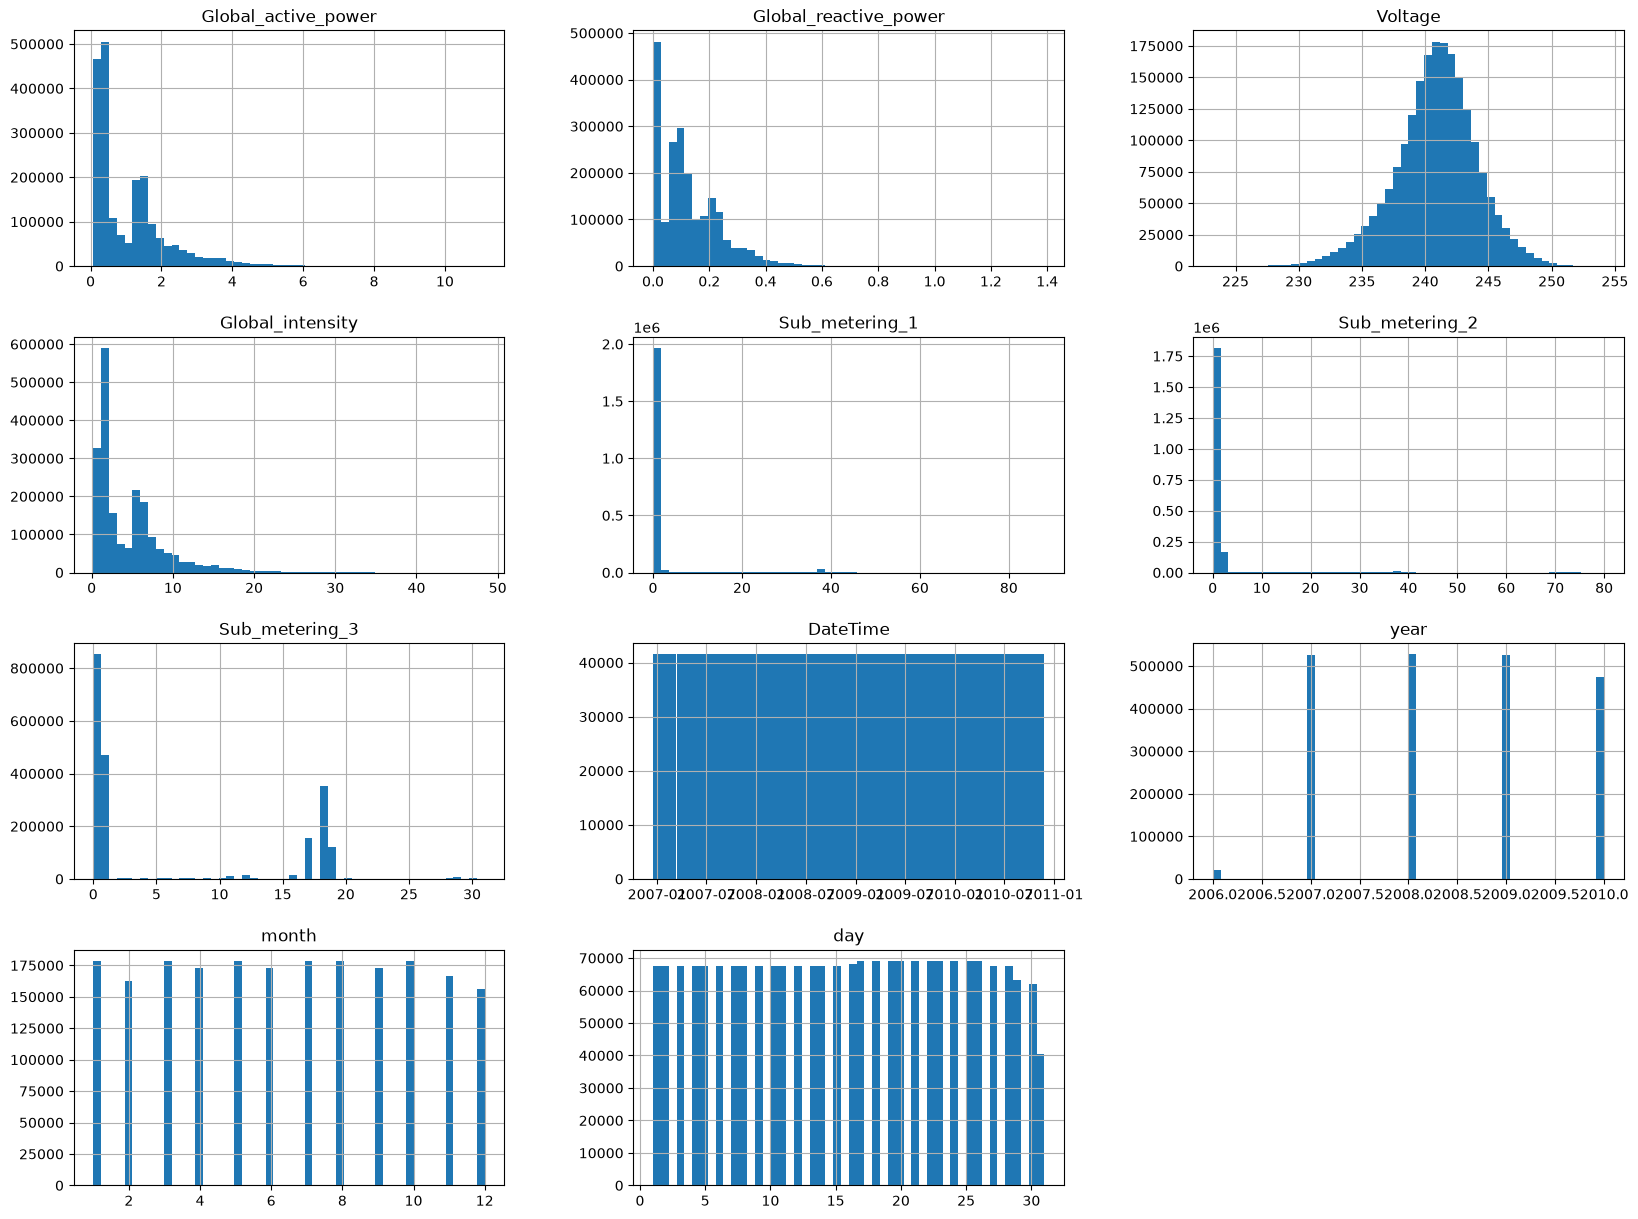

In [13]:
# Visualize the distributions using histograms
power.hist(bins=50, figsize=(20,15))

array([[<Axes: xlabel='Global_active_power', ylabel='Global_active_power'>,
        <Axes: xlabel='Global_reactive_power', ylabel='Global_active_power'>,
        <Axes: xlabel='Voltage', ylabel='Global_active_power'>,
        <Axes: xlabel='Global_intensity', ylabel='Global_active_power'>,
        <Axes: xlabel='Sub_metering_1', ylabel='Global_active_power'>,
        <Axes: xlabel='Sub_metering_2', ylabel='Global_active_power'>,
        <Axes: xlabel='Sub_metering_3', ylabel='Global_active_power'>],
       [<Axes: xlabel='Global_active_power', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Global_reactive_power', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Voltage', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Global_intensity', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Sub_metering_1', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Sub_metering_2', ylabel='Global_reactive_power'>,
        <Axes: xlabel='Sub_metering_3', ylabel='Gl

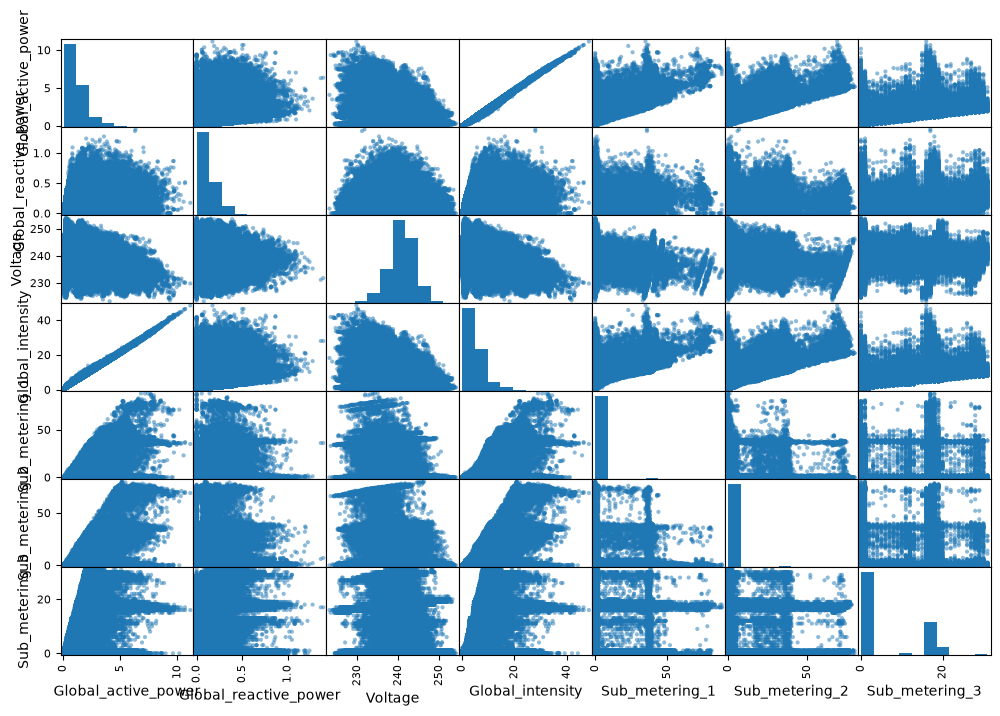

In [14]:
# Visualize the correlation between the features
attributes = ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]
scatter_matrix(power[attributes], figsize=(12, 8))

## Preprocessing

### Data Cleaning

In [15]:
# Fill in missing values with the mean using an imputer
imputer = SimpleImputer(strategy="median")
imputer.fit(power[attributes])
power[attributes] = imputer.transform(power[attributes])

In [16]:
# Check for missing values
power.isna().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
DateTime                 0
year                     0
month                    0
day                      0
dtype: int64

array([[<Axes: xlabel='Global_active_power', ylabel='Global_active_power'>,
        <Axes: xlabel='month', ylabel='Global_active_power'>,
        <Axes: xlabel='year', ylabel='Global_active_power'>,
        <Axes: xlabel='day', ylabel='Global_active_power'>,
        <Axes: xlabel='Voltage', ylabel='Global_active_power'>],
       [<Axes: xlabel='Global_active_power', ylabel='month'>,
        <Axes: xlabel='month', ylabel='month'>,
        <Axes: xlabel='year', ylabel='month'>,
        <Axes: xlabel='day', ylabel='month'>,
        <Axes: xlabel='Voltage', ylabel='month'>],
       [<Axes: xlabel='Global_active_power', ylabel='year'>,
        <Axes: xlabel='month', ylabel='year'>,
        <Axes: xlabel='year', ylabel='year'>,
        <Axes: xlabel='day', ylabel='year'>,
        <Axes: xlabel='Voltage', ylabel='year'>],
       [<Axes: xlabel='Global_active_power', ylabel='day'>,
        <Axes: xlabel='month', ylabel='day'>,
        <Axes: xlabel='year', ylabel='day'>,
        <Axes: xlabel=

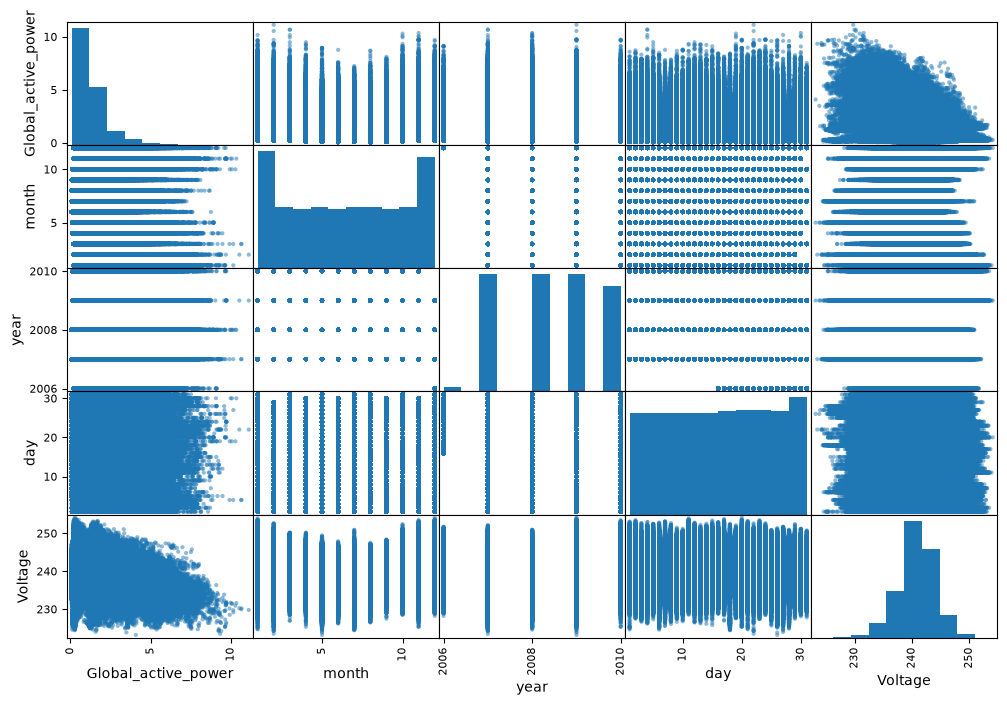

In [17]:
# Visualize the correlation between the features
scatter_matrix(power[["Global_active_power", "month", "year", "day", "Voltage"]], figsize=(12, 8))

In [18]:
# View the dataframes info
power.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 13 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   str           
 1   Time                   str           
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   DateTime               datetime64[us]
 10  year                   int32         
 11  month                  int32         
 12  day                    int32         
dtypes: datetime64[us](1), float64(7), int32(3), str(2)
memory usage: 182.1 MB


In [19]:
# Drop the Date, Time, and DateTime columns from the entire data set
power = power.drop(["Date", "Time", "DateTime"], axis=1)

## Split the data into train and test sets

In [20]:
# Split the dataset into train and test sets 80/20
# Could use stratified split

train_set, test_set = train_test_split(power, test_size=0.2, random_state=24)

## Apply Linear Regression Model

In [21]:
# Get the features (columns used in prediction) and the target (what you are trying to predict) from the test set
power_features = train_set.drop("Global_active_power", axis=1) # Drop Global_active_power column for features
power_labels = train_set["Global_active_power"].copy() # Copy Global_active_power column for labels

In [22]:
#Use a Linear Regression model
lin_reg = LinearRegression()
# Training the model on the features and the target
lin_reg.fit(power_features, power_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.18, 0. , 0.24,..., 0. , 0. , 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['Global_reactive_power','Voltage','Global_intensity',...,'year','month', 'day']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.156
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


## Accuracy of the model

In [23]:
#Get the RMSE for the model
gPower_predictions = lin_reg.predict(power_features)
lin_mse = mean_squared_error(power_labels, gPower_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(0.0403607370658686)

In [24]:
#Get the MAE for the model
lin_mae = mean_absolute_error(power_labels, gPower_predictions)
lin_mae

0.025597283345540303

## Better Evaluation Using Cross-Validation

In [25]:
# Cross-validation with 10 folds
scores = cross_val_score(lin_reg, power_features, power_labels,
                         scoring="neg_mean_squared_error", cv=10)
# Get the RMSE for the model
lin_reg_rmse_scores = np.sqrt(-scores)

In [26]:
# Display the scores, score mean, and score standard deviation
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(lin_reg_rmse_scores)

Scores: [0.04057875 0.04062943 0.04007354 0.04069968 0.03992522 0.04075163
 0.04015361 0.04021545 0.04015391 0.04042164]
Mean: 0.04036028561681966
Standard deviation: 0.00027749838604905806


## Apply the model to the test set

In [27]:
# Get the features (columns used in prediction) and the target/label (what you are trying to predict) from the test set
X_test = test_set.drop("Global_active_power", axis=1) # Drop Global_active_power column for features
Y_test = test_set["Global_active_power"].copy() # Copy Global_active_power column for labels

In [28]:
# Run the model on the test set
final_predictions = lin_reg.predict(X_test)

In [29]:
# Get the RMSE for the model on the test set
final_mse = mean_squared_error(Y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_rmse

np.float64(0.040354427171289495)

In [30]:
# Get the MAE for the model on the test set
final_mae = mean_absolute_error(Y_test, final_predictions)
final_mae

0.02557678717525744